In [ ]:
%pip install python-docx

Chapter 3.1 Figure

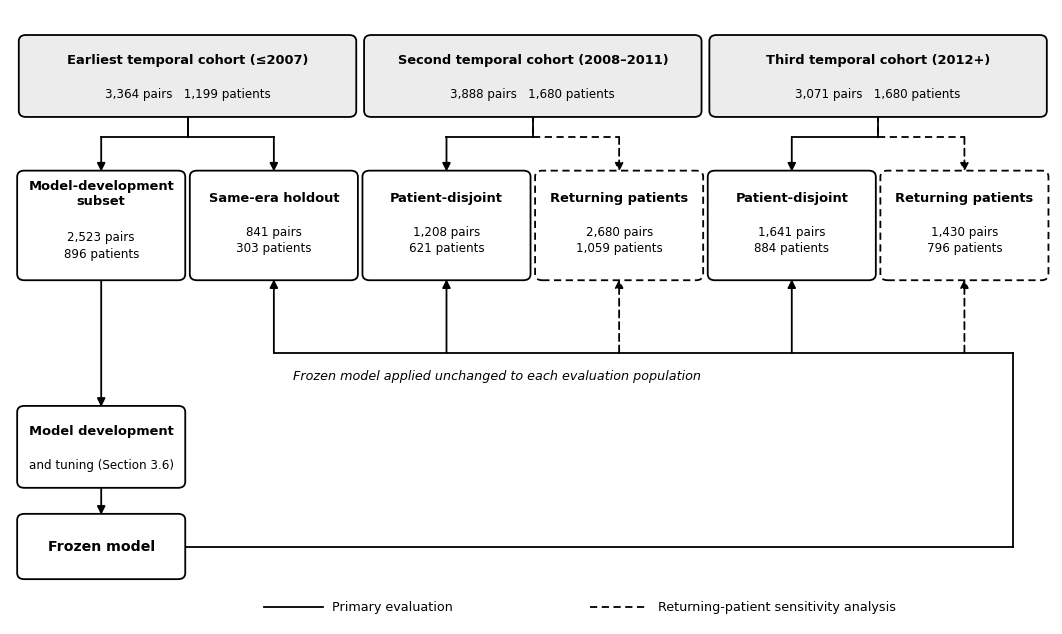

saved figures/figure_3_1_architecture.svg and .png


In [2]:
# Figure 3.1 — model-development and temporal evaluation architecture.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

Path('figures').mkdir(exist_ok=True)

# counts from file
arch = pd.read_csv('population_architecture.csv')
arch['Population'] = arch['Population'].str.strip()


def counts(population, period, stacked=False):
    row = arch[(arch.Population == population) & (arch.Period == period)]
    assert len(row) == 1, f'expected one row for {population}, {period}'
    row = row.iloc[0]
    sep = '\n' if stacked else '   '
    return f"{int(row.Pairs):,} pairs{sep}{int(row.Patients):,} patients"


# drawing
plt.rcParams['font.family'] = 'DejaVu Sans'
INK, FILL, SHADE = '#000000', '#ffffff', '#ececec'
SOLID, DASHED = '-', (0, (4, 2.5))

fig, ax = plt.subplots(figsize=(10.5, 6.2))
ax.set_xlim(-1, 159)
ax.set_ylim(-7, 104)
ax.axis('off')


def box(x, y, w, h, title, sub=None, dashed=False, shade=False, fs=9.4):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle='round,pad=0.4,rounding_size=1.1',
                                linewidth=1.3, edgecolor=INK,
                                facecolor=SHADE if shade else FILL,
                                linestyle=DASHED if dashed else SOLID, zorder=3))
    if sub:
        two, two_title = '\n' in sub, '\n' in title
        ty = y + (5.8 if two_title else 5.0 if two else 2.8)
        sy = y - (3.6 if two_title else 2.6 if two else 3.2)
        ax.text(x, ty, title, ha='center', va='center', fontsize=fs,
                fontweight='bold', color=INK, linespacing=1.15, zorder=4)
        ax.text(x, sy, sub, ha='center', va='center',
                fontsize=fs - 0.8, color=INK, linespacing=1.35, zorder=4)
    else:
        ax.text(x, y, title, ha='center', va='center', fontsize=fs + 0.8,
                fontweight='bold', color=INK, zorder=4)
    return {'x': x, 'top': y + h / 2, 'bot': y - h / 2, 'r': x + w / 2, 'y': y}


def line(xs, ys, dashed=False):
    ax.plot(xs, ys, color=INK, lw=1.3, linestyle=DASHED if dashed else SOLID, zorder=2)


def arrow(p0, p1, dashed=False):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle='-|>', mutation_scale=12,
                                 linewidth=1.3, color=INK,
                                 linestyle=DASHED if dashed else SOLID,
                                 shrinkA=0, shrinkB=1, zorder=2))


YC, YK, YB = 92, 65, 42
W, H, HK = 25, 14, 19

c1 = box(26.25, YC, 51, H, 'Earliest temporal cohort (\u22642007)',
         counts('Earliest temporal cohort', '<=2007'), shade=True)
c2 = box(79.25, YC, 51, H, 'Second temporal cohort (2008\u20132011)',
         counts('Second temporal cohort', '2008-2011'), shade=True)
c3 = box(132.25, YC, 51, H, 'Third temporal cohort (2012+)',
         counts('Third temporal cohort', '2012+'), shade=True)

dev = box(13, YK, W, HK, 'Model-development\nsubset',
          counts('Model-development subset', '<=2007', stacked=True))
hold = box(39.5, YK, W, HK, 'Same-era holdout',
           counts('Same-era holdout', '<=2007', stacked=True))
new2 = box(66, YK, W, HK, 'Patient-disjoint',
           counts('patient-disjoint', '2008-2011', stacked=True))
ret2 = box(92.5, YK, W, HK, 'Returning patients',
           counts('Returning patients', '2008-2011', stacked=True), dashed=True)
new3 = box(119, YK, W, HK, 'Patient-disjoint',
           counts('patient-disjoint', '2012+', stacked=True))
ret3 = box(145.5, YK, W, HK, 'Returning patients',
           counts('Returning patients', '2012+', stacked=True), dashed=True)

for parent, kids in [(c1, (dev, hold)), (c2, (new2, ret2)), (c3, (new3, ret3))]:
    for kid in kids:
        d = kid is ret2 or kid is ret3
        line([parent['x'], parent['x']], [parent['bot'], parent['bot'] - 4], d)
        line([parent['x'], kid['x']], [parent['bot'] - 4, parent['bot'] - 4], d)
        arrow((kid['x'], parent['bot'] - 4), (kid['x'], kid['top']), d)

mdl = box(13, 25, W, H, 'Model development', 'and tuning (Section 3.6)')
frz = box(13, 7, W, 11, 'Frozen model')
arrow((dev['x'], dev['bot']), (mdl['x'], mdl['top']))
arrow((mdl['x'], mdl['bot']), (frz['x'], frz['top']))

line([frz['r'], 153], [frz['y'], frz['y']])
line([153, 153], [frz['y'], YB])
line([hold['x'], 153], [YB, YB])
for b, d in [(hold, False), (new2, False), (ret2, True), (new3, False), (ret3, True)]:
    arrow((b['x'], YB), (b['x'], b['bot']), d)

ax.text(42.5, YB - 3.0, 'Frozen model applied unchanged to each evaluation population',
        fontsize=9.2, color=INK, va='top', style='italic')

line([38, 47], [-4, -4])
ax.text(48.5, -4, 'Primary evaluation', fontsize=9.2, va='center', color=INK)
line([88, 97], [-4, -4], dashed=True)
ax.text(98.5, -4, 'Returning-patient sensitivity analysis', fontsize=9.2,
        va='center', color=INK)

plt.tight_layout(pad=0.2)
fig.savefig('figures/figure_3_1_architecture.svg', bbox_inches='tight',
            facecolor='white')
fig.savefig('figures/figure_3_1_architecture.png', dpi=400, bbox_inches='tight',
            facecolor='white')
plt.show()
print('saved figures/figure_3_1_architecture.svg and .png')

# Chapter 4 Tables 

In [ ]:
from pathlib import Path

import pandas as pd
from docx import Document
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.shared import Pt

OUT = Path('chapter4_tables.docx')
doc = Document()
doc.styles['Normal'].font.size = Pt(10)


def add_table(number, caption, frame, note=None, align_first_left=True):
    """Write one captioned table. Values are written exactly as supplied."""
    p = doc.add_paragraph()
    r = p.add_run(f'Table {number}. ')
    r.bold = True
    p.add_run(caption)

    t = doc.add_table(rows=1, cols=len(frame.columns))
    t.style = 'Table Grid'
    for j, col in enumerate(frame.columns):
        cell = t.rows[0].cells[j]
        cell.text = str(col)
        for run in cell.paragraphs[0].runs:
            run.bold = True

    for _, row in frame.iterrows():
        cells = t.add_row().cells
        for j, val in enumerate(row):
            if pd.isna(val):
                text = ''
            elif isinstance(val, float):
                text = f'{val:.3f}'          # avoid float artefacts and lost zeros
            else:
                text = str(val)
            cells[j].text = text
            if j > 0 or not align_first_left:
                cells[j].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.RIGHT

    if note:
        np_ = doc.add_paragraph()
        nr = np_.add_run(note)
        nr.italic = True
        nr.font.size = Pt(8.5)
    doc.add_paragraph()


# -Table 4.1
arch = pd.read_csv('population_architecture.csv')
desc = pd.read_csv('rq2_descriptive_distributions.csv', index_col=0)
miss = pd.read_csv('rq2_missingness_by_population.csv', index_col=0)

cols = list(desc.columns)                      # reference + two later populations
wanted = ['Earliest temporal cohort', '  patient-disjoint', '  patient-disjoint']
periods = ['<=2007', '2008-2011', '2012+']
counts = []
for lab, per in zip(wanted, periods):
    row = arch[(arch.Population == lab) & (arch.Period == per)].iloc[0]
    counts.append(row)

LABELS = {'agefu': 'Age at visit', 'disease_duration': 'Disease duration, years',
          'bmi': 'Body mass index', 'tend_28jt': 'Tender joint count',
          'swollen_28jt': 'Swollen joint count', 'esr_score': 'ESR',
          'Days_on_Steroids': 'Steroid exposure, days',
          'Days_on_DMARDs': 'DMARD exposure, days',
          'comorbidity_count': 'Comorbidity count', 'gender': 'Sex',
          'sc': 'Socioeconomic classification', 'biologic_exposed': 'Biologic exposure'}

rows = [['Prediction pairs'] + [f'{int(c.Pairs):,}' for c in counts],
        ['Patients'] + [f'{int(c.Patients):,}' for c in counts],
        ['Active at following visit'] + [f'{c["Active %"]:.1f}%' for c in counts]]
for v, lab in LABELS.items():
    rows.append([lab] + [desc.loc[v, c] for c in cols])
rows.append(['ESR missing'] + [f'{miss.loc["esr_score", c]:.1f}%' for c in cols])

t41 = pd.DataFrame(rows, columns=['', 'Earliest cohort',
                                  '2008\u20132011 patient-disjoint', '2012+ patient-disjoint'])
add_table('4.1', 'Characteristics of the earliest temporal cohort and the later '
                 'patient-disjoint evaluation populations', t41,
          note='Continuous variables are mean (SD); categorical variables show the '
               'modal category. The earliest temporal cohort is shown here for '
               'population description and corresponds to the reference population '
               'used for RQ2. RQ1 and RQ3 use the patient-level same-era holdout as '
               'their evaluation baseline, as defined in Section 3.5.')

# -Table 4.2
perf = pd.read_csv('temporal_performance_primary.csv')
t42 = perf[['Population', 'Model', 'Prevalence', 'Mean predicted',
            'ROC-AUC [95% CI]', 'Brier [95% CI]', 'Brier skill [95% CI]']].copy()
t42.columns = ['Population', 'Model', 'Observed prevalence', 'Mean predicted',
               'ROC-AUC [95% CI]', 'Brier [95% CI]', 'Brier skill [95% CI]']
add_table('4.2', 'Performance of the frozen models on unseen-patient populations', t42,
          note='Intervals are 95% percentile intervals from 1,000 patient-clustered '
               'bootstrap replicates.')

# - Table 4.3
shift = pd.read_csv('rq2_distributional_shift.csv')
t43 = shift[['Population', 'Predictor', 'Type', 'PSI', 'PSI 95% CI', 'KS']].copy()
t43 = t43.sort_values(['Population', 'PSI'], ascending=[True, False])
add_table('4.3', 'Distributional shift in model predictors relative to the earliest '
                 'temporal cohort', t43,
          note='PSI, population stability index; KS, Kolmogorov-Smirnov statistic, '
               'reported for continuous predictors only. Intervals are 95% percentile '
               'intervals from 1,000 patient-clustered bootstrap replicates.')

# -Table 4.4
INCLUDE_RAW_MAGNITUDE = False   # set True to keep the mean |SHAP| columns

imp = pd.read_csv('rq3_global_importance.csv', header=[0, 1], index_col=0)
if not INCLUDE_RAW_MAGNITUDE:
    imp = imp.loc[:, [c for c in imp.columns if c[0] != 'mean |SHAP|']]
short = {'Same-era holdout (\u22642007)': 'Holdout',
         '2008\u20132011 patient-disjoint': '2008\u20132011',
         '2012+ patient-disjoint': '2012+'}
imp.columns = [f'{a} \u2014 {short.get(b, b)}' for a, b in imp.columns]
t44 = imp.reset_index().rename(columns={imp.index.name or 'index': 'Predictor'})
add_table('4.4', 'Global feature attribution of the frozen random forest by '
                 'evaluation population', t44,
          note="Values are each predictor's share of total mean absolute SHAP "
               'attribution and corresponding rank within the evaluation population. '
               'Attributions were calculated on the probability scale.')

# - Table 4.5
stab = pd.read_csv('rq3_ranking_stability.csv')
sens = pd.read_csv('rq3_sensitivity_analyses.csv')

blocks = [['Primary analysis \u2014 random forest, interventional TreeSHAP', '', '', '']]
for _, r in stab.iterrows():
    blocks.append([r['Comparison'], f"{r['Spearman rho']:.3f}",
                   r['rho 95% CI'], r['Top-5 overlap']])
blocks.append(['Sensitivity analyses \u2014 path-dependent TreeSHAP', '', '', ''])
for _, r in sens.iterrows():
    blocks.append([f"{r['Model']}, {r['Comparison']}",
                   f"{r['rho (path-dependent)']:.3f}", '\u2014', r['Top-5 overlap']])

t45 = pd.DataFrame(blocks, columns=['Comparison', "Spearman's rho", '95% CI',
                                    'Top-5 overlap'])
add_table('4.5', 'Temporal stability of feature attribution and sensitivity analyses',
          t45,
          note='Bootstrap intervals were calculated for the pre-specified primary '
               'analysis only and were not repeated for the sensitivity analyses; '
               'dashes therefore indicate that confidence intervals were not calculated.')

doc.save(OUT)
print(f'saved {OUT.resolve()}')
for tbl, n in [('4.1', len(t41)), ('4.2', len(t42)), ('4.3', len(t43)),
               ('4.4', len(t44)), ('4.5', len(t45))]:
    print(f'  Table {tbl}: {n} rows')


# Build Figures 4.2 and 4.3 for Chapter 4 from the saved analysis outputs.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Path('figures').mkdir(exist_ok=True)

LABELS = {'agefu': 'Age at visit', 'disease_duration': 'Disease duration',
          'bmi': 'Body mass index', 'tend_28jt': 'Tender joint count',
          'swollen_28jt': 'Swollen joint count', 'esr_score': 'ESR',
          'Days_on_Steroids': 'Steroid exposure', 'Days_on_DMARDs': 'DMARD exposure',
          'comorbidity_count': 'Comorbidity count', 'gender': 'Sex',
          'sc': 'Socioeconomic classification', 'biologic_exposed': 'Biologic exposure'}

EARLY = '2008\u20132011 patient-disjoint'
LATE = '2012+ patient-disjoint'
BASE = 'Same-era holdout'
C_BASE = '#2F4B66'
C_EARLY = '#4C78A8'
C_LATE = '#9C4F5C'


# - Figure 4.2, RQ2 shift
shift = pd.read_csv('rq2_distributional_shift.csv')
ci = shift['PSI 95% CI'].str.strip('[]').str.split(',', expand=True).astype(float)
shift['lo'], shift['hi'] = ci[0], ci[1]
shift['pop'] = np.where(shift.Population.str.startswith('2012'), LATE, EARLY)
shift['label'] = shift.Predictor.map(LABELS)

order = (shift[shift['pop'] == LATE].sort_values('PSI').label.tolist())
pos = {lab: i for i, lab in enumerate(order)}

fig, ax = plt.subplots(figsize=(7.6, 5.2))
offset = 0.17
for pop, colour, dy in [(EARLY, C_EARLY, -offset), (LATE, C_LATE, offset)]:
    sub = shift[shift['pop'] == pop]
    y = [pos[l] + dy for l in sub.label]
    ax.errorbar(sub.PSI, y,
                xerr=[sub.PSI - sub.lo, sub.hi - sub.PSI],
                fmt='o', ms=5, lw=1.1, capsize=2.5, color=colour, label=pop, zorder=3)

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel('Population stability index (95% CI)')
ax.set_xlim(left=0)
ax.grid(axis='x', alpha=.25)
ax.legend(fontsize=8.5, loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('figures/fig4_2_predictor_shift.png', dpi=300, bbox_inches='tight')
plt.close()
print('saved figures/fig4_2_predictor_shift.png')


# - Figure 4.3, RQ3 attribution share
imp = pd.read_csv('rq3_global_importance.csv', header=[0, 1], index_col=0)
share = imp['share %']
share.columns = [BASE if 'holdout' in c else (LATE if c.startswith('2012') else EARLY)
                 for c in share.columns]
share.index = [LABELS[v] for v in share.index]
share = share.loc[share[BASE].sort_values().index]          # ascending, so rank 1 on top

fig, ax = plt.subplots(figsize=(7.6, 5.2))
for lab in share.index:
    ax.plot(share.loc[lab], [lab] * 3, color='#b0b0b0', lw=1.0, zorder=1)
for pop, colour, marker in [(BASE, C_BASE, 'o'), (EARLY, C_EARLY, 's'),
                            (LATE, C_LATE, '^')]:
    ax.scatter(share[pop], share.index, s=42, color=colour, marker=marker,
               label=pop, zorder=3)

ax.set_xlabel('Share of total mean absolute SHAP attribution (%)')
ax.set_xlim(left=-1)
ax.tick_params(labelsize=9)
ax.grid(axis='x', alpha=.25)
ax.legend(fontsize=8.5, loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig('figures/fig4_3_attribution_share.png', dpi=300, bbox_inches='tight')
plt.close()
print('saved figures/fig4_3_attribution_share.png')


saved figures/fig4_2_predictor_shift.png
saved figures/fig4_3_attribution_share.png
